# 03 — Análise de Detecção Multi-Modal

Gera um dataset real (scores das 4 modalidades -> rótulo de ataque) rodando `GRADFFederatedLearner`/`AttackedFederatedLearner` sob ataques reais (`src.utils.data_loader.generate_detection_dataset`, Fase 2) e analisa a separação entre updates honestos e atacados em cada modalidade.

In [1]:
import sys, os
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from src.detection.combiner_nn import DetectionCombiner
from src.utils.data_loader import generate_detection_dataset, load_dataset_participants

os.makedirs('../results/figures', exist_ok=True)

DATASET, SPLIT, N_CLIENTS, N_CLASSES = 'mnist', 'non_iid', 10, 10
ATTACK_TYPES = ['sign_flipping', 'gaussian_noise', 'label_flipping']
participants, root_data = load_dataset_participants(DATASET, SPLIT, N_CLIENTS, data_root='../data/processed')

I0000 00:00:1785807355.035268 1114783 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785807355.035836 1114783 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785807355.065735 1114783 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785807355.883435 1114783 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785807355.883767 1114783 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
X, y_binary, y_attack_type = generate_detection_dataset(
    participants, n_rounds=12, attack_types=ATTACK_TYPES,
    byzantine_fraction=0.3, aggregation='fedavg', n_classes=N_CLASSES, seed=1)
print(f'{len(X)} amostras | honestas={sum(y_binary==0)} atacadas={sum(y_binary==1)}')

480 amostras | honestas=372 atacadas=108


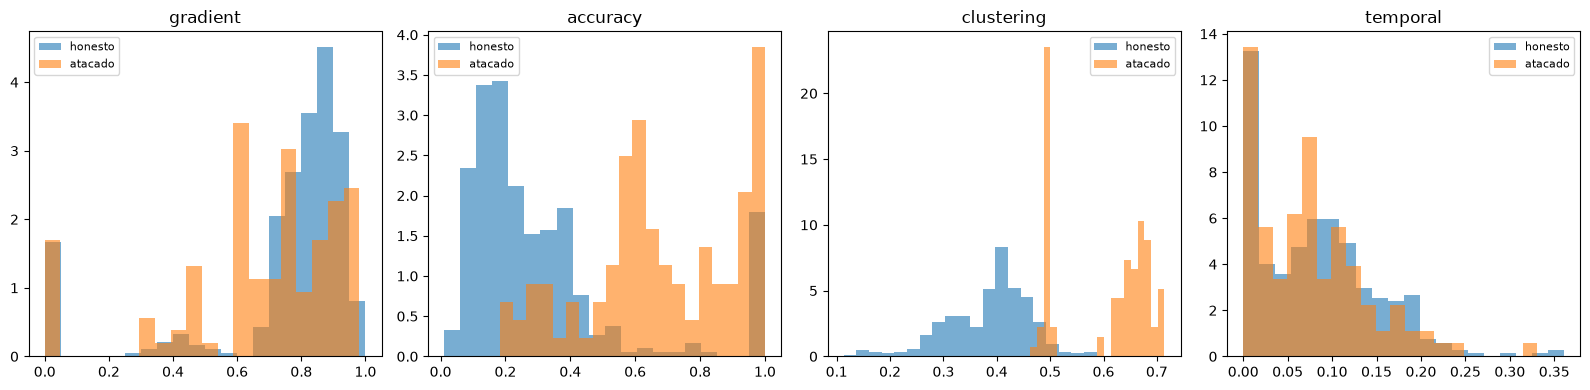

In [3]:
MODALITY_NAMES = ['gradient', 'accuracy', 'clustering', 'temporal']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, name in enumerate(MODALITY_NAMES):
    axes[i].hist(X[y_binary == 0, i], bins=20, alpha=0.6, label='honesto', density=True)
    axes[i].hist(X[y_binary == 1, i], bins=20, alpha=0.6, label='atacado', density=True)
    axes[i].set_title(name)
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig('../results/figures/03_detection_modality_distributions.png', bbox_inches='tight')
plt.show()

In [4]:
combiner = DetectionCombiner()
losses = combiner.train(X, y_binary, epochs=30, batch_size=32, verbose=False)
preds = combiner.predict(X)
accuracy = float(np.mean((preds > 0.5) == y_binary))
print(f'Loss inicial={losses[0]:.4f} -> final={losses[-1]:.4f}')
print(f'Acurácia do combiner no próprio dataset de treino: {accuracy:.2%}')
combiner.save('../results/models/combiner_nn.weights.h5')

E0000 00:00:1785807392.304548 1114783 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1785807392.325543 1114783 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Loss inicial=0.6283 -> final=0.1365
Acurácia do combiner no próprio dataset de treino: 96.67%
